In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/processed/cleaned_marketing.csv')
df.head()

,campaign_name,date,spend_usd,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase,group
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,control


In [3]:
df['date'] = pd.to_datetime(df['date'])

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   campaign_name   60 non-null     str           
 1   date            60 non-null     datetime64[us]
 2   spend_usd       60 non-null     int64         
 3   impressions     59 non-null     float64       
 4   reach           59 non-null     float64       
 5   website_clicks  59 non-null     float64       
 6   searches        59 non-null     float64       
 7   view_content    59 non-null     float64       
 8   add_to_cart     59 non-null     float64       
 9   purchase        59 non-null     float64       
 10  group           60 non-null     str           
dtypes: datetime64[us](1), float64(7), int64(1), str(2)
memory usage: 6.5 KB


In [5]:
# Xét nhóm nào có tỉ lệ mua cao hơn
group_purchase = df.groupby('group')['purchase'].mean()
print(group_purchase)

group
control    522.793103
test       521.233333
Name: purchase, dtype: float64


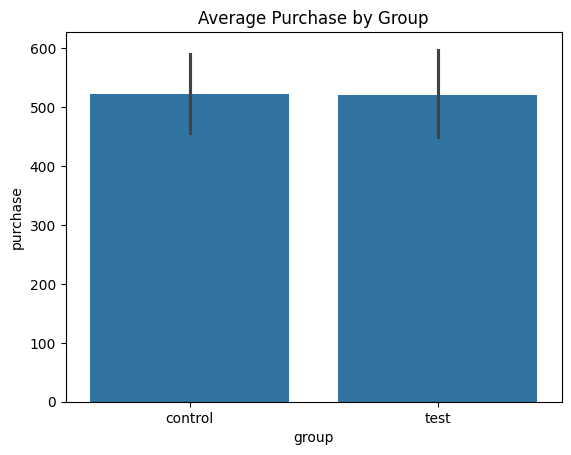

In [6]:
sns.barplot(
    x='group',
    y='purchase',
    data=df
)
plt.title('Average Purchase by Group')
plt.show()

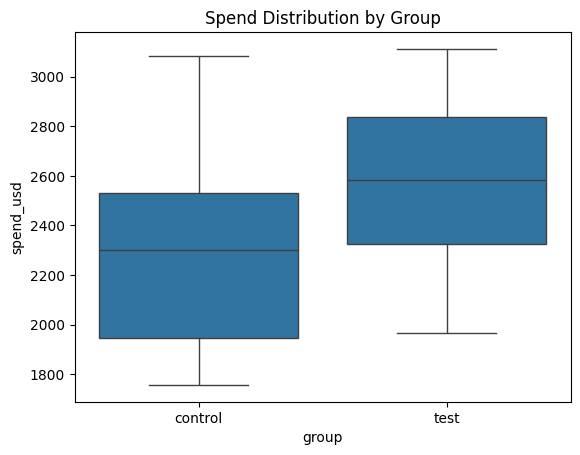

In [7]:
sns.boxplot(
    x='group',
    y='spend_usd',
    data=df
)

plt.title('Spend Distribution by Group')
plt.show()

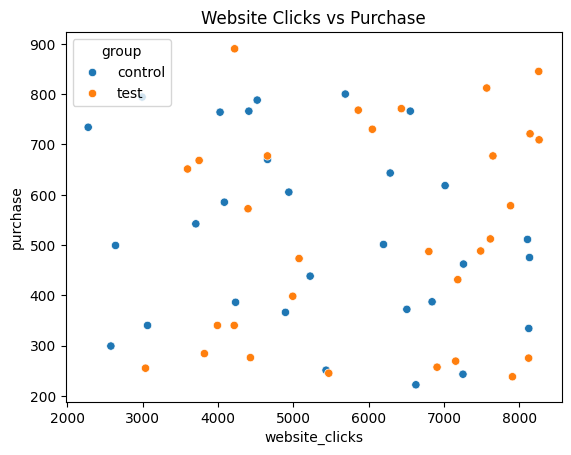

In [8]:
sns.scatterplot(
    x='website_clicks',
    y='purchase',
    hue='group',
    data=df
)
plt.title('Website Clicks vs Purchase')
plt.show()

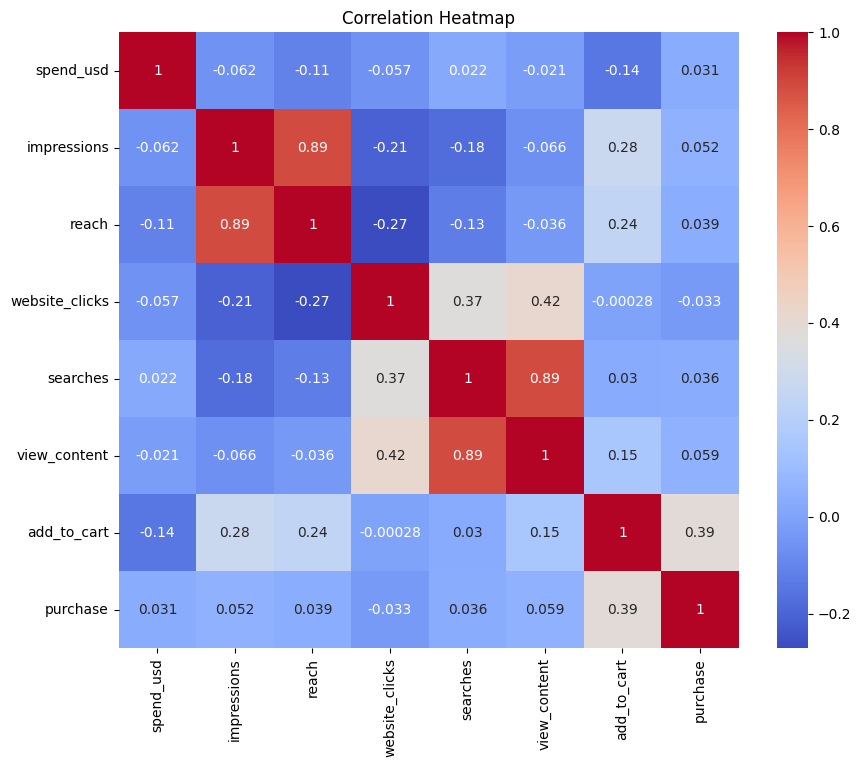

In [9]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

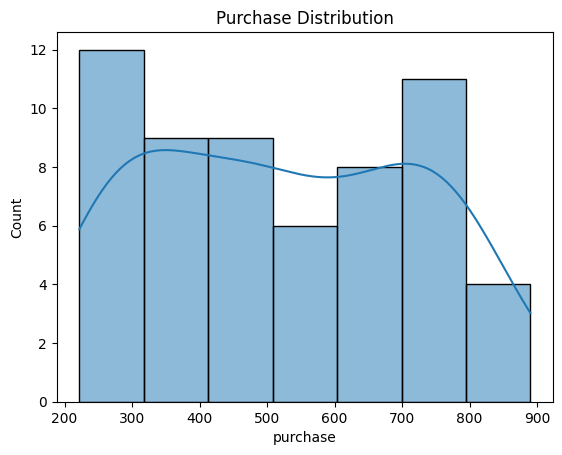

In [10]:
sns.histplot(
    df['purchase'],
    kde=True
)
plt.title('Purchase Distribution')
plt.show()

In [11]:
df.groupby('group').agg({
    'purchase':['mean','sum','max'],
    'website_clicks':['mean'],
    'spend_usd':['mean']
})

purchase                 website_clicks    spend_usd
               mean      sum    max           mean         mean
group                                                          
control  522.793103  15161.0  800.0    5320.793103  2288.433333
test     521.233333  15637.0  890.0    6032.333333  2563.066667